# Bimodal Gaussian location model

### Setup

We simulate bimodal data from a two-component Gaussian mixture, which we denote $P_0$ (see below). We define a misspecified unimodal normal-location model in PyMC and sample its predictively oriented posterior with `sample_pro`. Under misspecification, the PrO posterior predictive for $y$ should place mass near both mixture modes (Theorem 1, McLatchie et al., [arXiv:2510.01915](https://arxiv.org/abs/2510.01915)).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

import pymc_prop as pro

az.style.use("arviz-variat")


## Simulate bimodal data

$$P_0 = 0.4\,\mathcal{N}(-1.5,\,0.7^2) + 0.6\,\mathcal{N}(2.25,\,0.7^2).$$

In [2]:
N = 800
sigma = 0.7
component_means = np.array([-1.5, 2.25])
component_weights = np.array([0.4, 0.6])
SEED = 2026

# draw component labels then observations -- reproducible rng
rng = np.random.default_rng(SEED)
components = rng.choice(len(component_means), size=N, p=component_weights)
y = rng.normal(loc=component_means[components], scale=sigma)

# plotting limits around component means
xlim = (component_means.min() - 3 * sigma, component_means.max() + 3 * sigma)

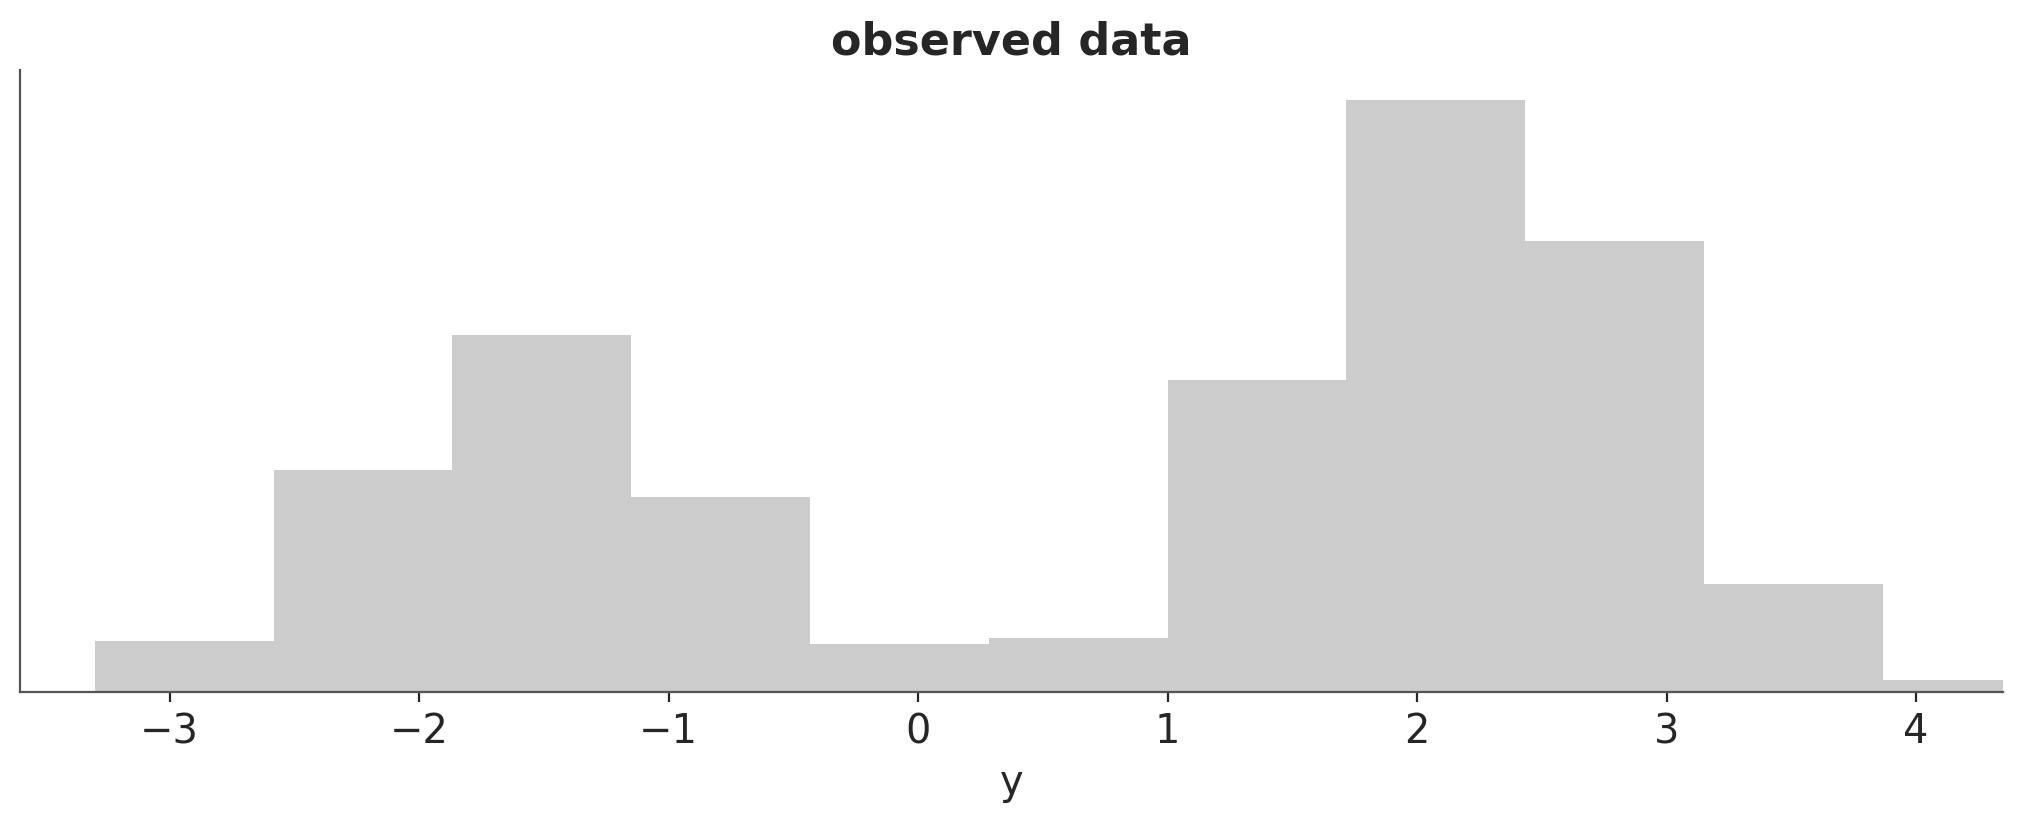

In [3]:
# histogram of the simulated data (verify bimodality)
_, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    y,
    bins="auto",
    color="0.8",
    edgecolor=None,
)
ax.set(title="observed data", xlabel="y", xlim=xlim, yticks=[]);


## PyMC model (misspecified unimodal likelihood)

We place a prior $\mathcal{N}(0, 1)$ on $\mu$ and define
$y_i \mid \mu \sim \mathcal{N}(\mu, \sigma^2)$ with known $\sigma$ (same as in $P_0$).

In [4]:
# misspecified normal-location model: prior N(0,1) on mu; known sigma
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)

### Run the sampler

Sampling uses a particle-discretized Wasserstein gradient flow on $N = 800$ observations. We set `tune=0` so every simulation step is retained for the trajectory plot (`n_steps` maps to the `draw` coordinate).

`sample_pro` includes in-sample posterior predictive sampling by default. Here we disable it and call `sample_posterior_predictive_pro` later so the PPC section stays explicit.

Demo settings: 40 particles, 2500 retained steps, step size `8e-4`, and learning rate $\lambda_n = 1$ (the default).


In [5]:
dt = pro.sample_pro(
    model=model,
    n_particles=40,
    n_steps=2500,
    step_size=8e-4,
    tune=0,
    random_seed=SEED,
    include_posterior_predictive=False,
)


## ArviZ DataTree output

`sample_pro` returns an ArviZ [DataTree](https://python.arviz.org/projects/base/en/latest/tutorial/WorkingWithDataTree.html). Coordinates: `draw` is the retained index, `step` is the simulation step number, and `chain` is the particle index. Particles are ensemble trajectories, not independent MCMC chains, so diagnostics such as `az.rhat` and `az.ess` are not meaningful here.

Key groups:

- `posterior`: particle clouds in unconstrained `value_vars` space.
- `log_likelihood`: per-particle elementwise $\log p(y_i \mid \theta^{(j)})$ with dims `(draw, chain, …)`.
- `mixture_log_predictive`: empirical mixture log predictive $\log p_{\hat Q}(y_i)$ at observed $y_i$ (dims `draw, …`, no `chain`).
- `sample_stats`: flow diagnostics. `mixture_log_predictive_total` sums mixture log predictive over observations (broadcast to `chain` for ArviZ layout). `mean_log_score` averages per-particle log-score sums, which is a different quantity.
- `posterior_predictive`: mixture PPC draws from `sample_posterior_predictive_pro` (or `sample_pro` when `include_posterior_predictive=True`). Shape `(draw, …)` with `sample_dims=["draw"]` — one row per retained step, aligned with `posterior.draw` / `step`, no `chain` dim.


In [6]:
dt

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (draw: 2500, chain: 40)
│       Coordinates:
│         * draw     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│           step     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│         * chain    (chain) int64 320B 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 39
│       Data variables:
│           mu       (draw, chain) float64 800kB 0.01728 1.24 -2.068 ... 2.067 2.46
│       Attributes:
│           created_at:                 2026-07-01T09:52:36.791382+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
├── Group: /observed_data
│       Dimensions:  (y_dim_0: 800)
│       Coordinates:
│         * y_dim_0  (y_dim_0) int64 6kB 0 1 2 3 4 5 6 7 ... 793 794 795 796 797 798 799
│       Data variables:
│           y        (y_dim_0) float64 6kB -1.696 2.014 2.631 ... 1.25 -0.3845 -2.138
│       Attributes:
│           created_at:                 2026-07-01T09:52:36.798547+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /log_likelihood
│       Dimensions:  (draw: 2500, chain: 40, y_dim_0: 800)
│       Coordinates:
│         * draw     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│           step     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│         * chain    (chain) int64 320B 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 39
│         * y_dim_0  (y_dim_0) int64 6kB 0 1 2 3 4 5 6 7 ... 793 794 795 796 797 798 799
│       Data variables:
│           y        (draw, chain, y_dim_0) float64 640MB -3.558 -4.63 ... -8.82 -22.14
│       Attributes:
│           created_at:                 2026-07-01T09:52:36.791382+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
├── Group: /sample_stats
│       Dimensions:                       (draw: 2500, chain: 40)
│       Coordinates:
│         * draw                          (draw) int64 20kB 0 1 2 3 ... 2497 2498 2499
│           step                          (draw) int64 20kB 0 1 2 3 ... 2497 2498 2499
│         * chain                         (chain) int64 320B 0 1 2 3 4 ... 36 37 38 39
│       Data variables:
│           particle_spread               (draw, chain) float64 800kB 1.841 ... 1.841
│           learning_rate                 (draw, chain) float64 800kB 1.0 1.0 ... 1.0
│           mu_spread                     (draw, chain) float64 800kB 1.841 ... 1.841
│           mean_log_score                (draw, chain) float64 800kB -6.439e+03 ... ...
│           se_log_score                  (draw, chain) float64 800kB 452.9 ... 252.7
│           mixture_log_predictive_total  (draw, chain) float64 800kB -1.722e+03 ... ...
│       Attributes:
│           created_at:                 2026-07-01T09:52:36.791382+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
└── Group: /mixture_log_predictive
        Dimensions:  (draw: 2500, y_dim_0: 800)
        Coordinates:
          * draw     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
            step     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
          * y_dim_0  (y_dim_0) int64 6kB 0 1 2

## Particle trajectories

Each line is one particle $\mu_t^{(j)}$. Under misspecification, trajectories often split across both true component means.

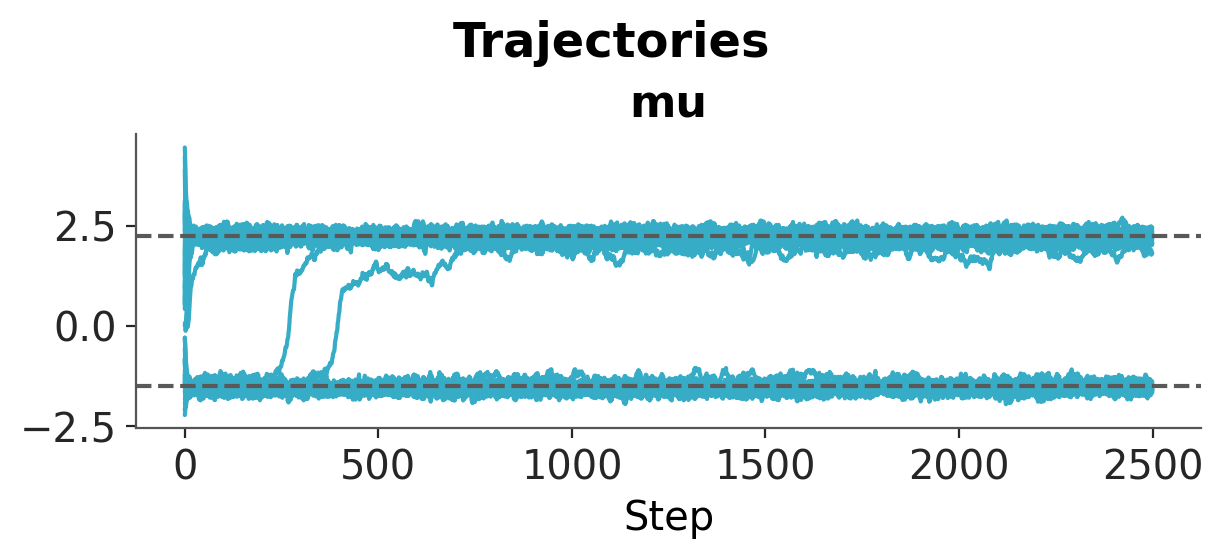

In [7]:
pc = az.plot_trace(
    dt,
    var_names=["mu"],
    aes={"color": False, "overlay": ["chain"]},
    visuals={"trace": {"color": "C0", "xname": "step"}},
)
pc = az.add_lines(
    pc,
    values=list(component_means),
    orientation="horizontal",
)
pc.add_title("Trajectories")


## Posterior predictive check

Theorem 1 is about the **marginal** PrO predictive $P_Q = \int P_\theta\, dQ(\theta)$ in observation space $\mathcal{Y}$.

`sample_posterior_predictive_pro` calls `pm.sample_posterior_predictive` on the full retained cloud (`sample_dims=["draw", "chain"]`), then remixes the per-particle grid into draw-aligned mixture PPC draws (`posterior_predictive` with `sample_dims=["draw"]`). `az.plot_ppc_dist` below overlays those mixture draws with the observed data.


In [8]:
ppc_dt = pro.sample_posterior_predictive_pro(
    dt,
    model=model,
    random_seed=SEED,
)


Sampling: [y]


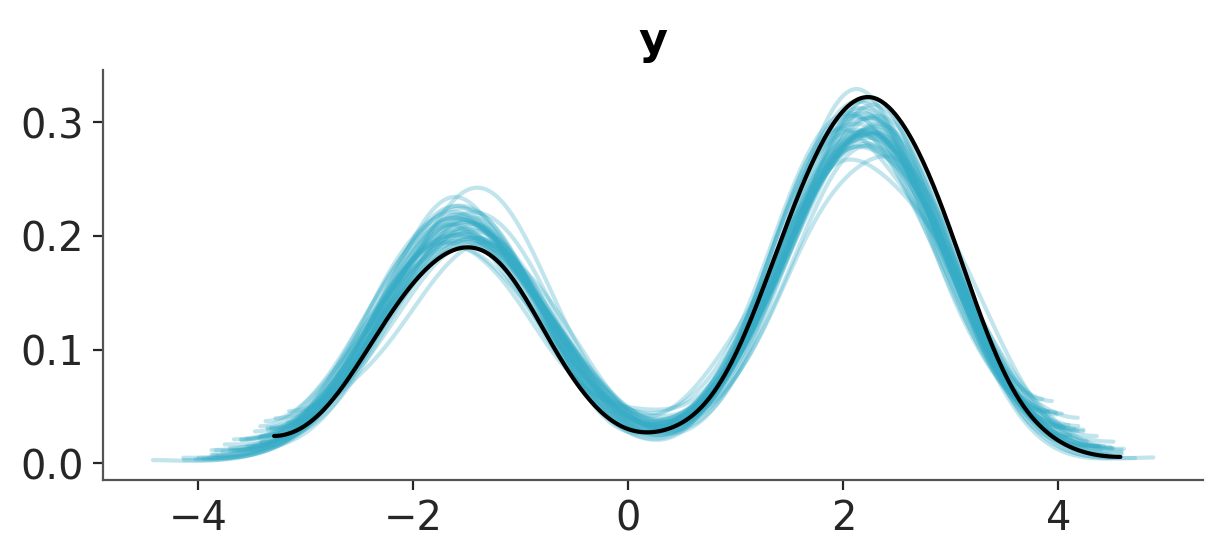

In [9]:
az.plot_ppc_dist(ppc_dt, num_samples=40);